# Monte Carlo Feature Simulation and Forecast Analysis

This document presents a **cell-level wildfire feature simulation** workflow for **t+7 probability forecasting**.

Study workflow:
1. Load the base wildfire feature table and the VIIRS feature table.
2. Merge the feature sources by `target_date`, `row`, `col`, and `window_id`.
3. Train the future-forecast MLP using Monte Carlo projected features.
4. Select one spatial cell using `date`, `row`, and `column`.
5. Simulate two selected features forward to `t+7`.
6. Present one final figure with Monte Carlo trajectories and mean paths.
7. Report:
   - current-day feature value
   - projected `t+7` feature mean and variance
   - initial fire probability at `t`
   - forecast fire probability at `t+7`


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch

candidate_roots = [Path('/kaggle/input/models/nagrajgaonkar/monte-carlo-sims/pytorch/futures/1')]
project_root = None
for p in candidate_roots:
    if (p / 'Futures').exists():
        project_root = p
        break
if project_root is None:
    raise RuntimeError('Could not find project root containing Futures/')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print('project_root:', project_root)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f'gpu[{i}]', torch.cuda.get_device_name(i))

project_root: /kaggle/input/models/nagrajgaonkar/monte-carlo-sims/pytorch/futures/1
torch: 2.10.0+cu128
cuda available: True
gpu count: 2
gpu[0] Tesla T4
gpu[1] Tesla T4


In [2]:
# Install once if needed
!pip -q install -U huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 10.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 62.2 MB/s eta 0:00:00a 0:00:01


## Data Sources

This section defines the three required data inputs:
- base feature CSVs
- VIIRS feature CSVs
- label CSVs

The feature and label tables may come from different repositories.


In [3]:
from huggingface_hub import hf_hub_download

# -----------------------------
# Separate Hugging Face repos
# -----------------------------
HF_FEATURES_REPO_ID = 'NagrajMG/WildFire-X'    # e.g. org/features-ds
HF_VIIRS_REPO_ID = 'NagrajMG/WildFire-X'       # e.g. org/viirs-ds or None to skip
HF_LABELS_REPO_ID = 'NagrajMG/WildFire-Y'      # e.g. org/labels-ds

HF_TOKEN = None                              
HF_FEATURES_REVISION = None
HF_VIIRS_REVISION = None
HF_LABELS_REVISION = None

FEATURES_BASE_NAME = 'FEATURES_train.csv'
FEATURES_VIIRS_NAME = 'FEATURES_train_viirs.csv'
LABELS_NAME = 'LABELS_train.csv'

cache_dir = Path('/kaggle/working/hf_cache')
cache_dir.mkdir(parents=True, exist_ok=True)


def _download(repo_id: str, filename: str, revision=None):
    return Path(hf_hub_download(
        repo_id=repo_id,
        filename=filename,
        repo_type='dataset',
        token=HF_TOKEN,
        revision=revision,
        cache_dir=str(cache_dir),
    ))

features_base_fp = _download(HF_FEATURES_REPO_ID, FEATURES_BASE_NAME, HF_FEATURES_REVISION)
labels_fp = _download(HF_LABELS_REPO_ID, LABELS_NAME, HF_LABELS_REVISION)

features_viirs_fp = None
if HF_VIIRS_REPO_ID is not None:
    try:
        features_viirs_fp = _download(HF_VIIRS_REPO_ID, FEATURES_VIIRS_NAME, HF_VIIRS_REVISION)
    except Exception as e:
        print('VIIRS file not downloaded:', e)
        features_viirs_fp = None

print('features_base_fp:', features_base_fp)
print('labels_fp      :', labels_fp)
print('features_viirs :', features_viirs_fp)

features_base_fp: /kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_train.csv
labels_fp      : /kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_train.csv
features_viirs : /kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_train_viirs.csv


In [4]:

from datetime import date, timedelta
from Futures.future_mc_forecast import (
    CellTrainingPoint,
    StreamingMCTrainConfig,
    train_future_probability_mlp_streaming_mc,
    run_recursive_future_forecast,
)

EXTRA_FEATURE_KEY_COLS = ('target_date', 'row', 'col', 'window_id')
CURRENT_PROBABILITY_COLUMN = 'ignition_prob_clim'


def _norm_key_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and standardize the key columns used to join all tables.

    The workflow relies on `target_date`, `row`, `col`, and `window_id`
    to align base features, VIIRS features, and labels. This helper ensures
    consistent typing and removes invalid rows before merging.
    """
    out = df.copy()
    out['target_date'] = pd.to_datetime(out['target_date'], errors='coerce').dt.date
    out['row'] = pd.to_numeric(out['row'], errors='coerce').astype('Int64')
    out['col'] = pd.to_numeric(out['col'], errors='coerce').astype('Int64')
    out['window_id'] = pd.to_numeric(out['window_id'], errors='coerce').astype('Int64')
    out = out.dropna(subset=['target_date', 'row', 'col', 'window_id'])
    out['row'] = out['row'].astype(np.int64)
    out['col'] = out['col'].astype(np.int64)
    out['window_id'] = out['window_id'].astype(np.int64)
    return out


def load_window_feature_tables(
    features_base_csv: Path,
    labels_csv: Path,
    features_viirs_csv: Path | None = None,
    extra_feature_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Load and merge the long-format feature tables used in the study.

    Output format:
    - one row per `(target_date, row, col, window_id)`
    - base feature columns
    - VIIRS feature columns when available
    - one supervised `label` per `(target_date, row, col)`

    Only cells with a complete four-window history are retained.
    """
    feat = pd.read_csv(features_base_csv)
    feat = _norm_key_columns(feat)

    key_cols = ['target_date', 'row', 'col', 'window_id']
    meta_cols = {'target_date', 'row', 'col', 'window_id', 'split', 'source_file'}

    if features_viirs_csv is not None and Path(features_viirs_csv).exists():
        viirs = pd.read_csv(features_viirs_csv)
        viirs = _norm_key_columns(viirs)
        viirs_feats = [c for c in viirs.columns if c not in key_cols and c not in {'split', 'source_file'}]
        viirs = viirs[key_cols + viirs_feats]
        feat = feat.merge(viirs, on=key_cols, how='left', suffixes=('', '_viirsdup'))
        dup_cols = [c for c in feat.columns if c.endswith('_viirsdup')]
        if dup_cols:
            feat = feat.drop(columns=dup_cols)
        print('Merged VIIRS features.')
    else:
        print('VIIRS merge skipped.')

    if extra_feature_df is not None:
        ex = _norm_key_columns(extra_feature_df)
        ex_feats = [c for c in ex.columns if c not in EXTRA_FEATURE_KEY_COLS]
        ex = ex[list(EXTRA_FEATURE_KEY_COLS) + ex_feats]
        feat = feat.merge(ex, on=key_cols, how='left', suffixes=('', '_extradup'))
        dup_cols = [c for c in feat.columns if c.endswith('_extradup')]
        if dup_cols:
            feat = feat.drop(columns=dup_cols)
        print('Merged extra in-memory vars.')

    labels = pd.read_csv(labels_csv)
    labels['target_date'] = pd.to_datetime(labels['target_date'], errors='coerce').dt.date
    labels['row'] = pd.to_numeric(labels['row'], errors='coerce')
    labels['col'] = pd.to_numeric(labels['col'], errors='coerce')
    labels['label'] = pd.to_numeric(labels['label'], errors='coerce')
    labels = labels.dropna(subset=['target_date', 'row', 'col', 'label']).copy()
    labels['row'] = labels['row'].astype(np.int64)
    labels['col'] = labels['col'].astype(np.int64)
    labels = labels[['target_date', 'row', 'col', 'label']].drop_duplicates(['target_date', 'row', 'col'])

    df = feat.merge(labels, on=['target_date', 'row', 'col'], how='inner')

    # Retain only keys with all four 16-day windows.
    win_counts = df.groupby(['target_date', 'row', 'col'], sort=False)['window_id'].nunique()
    keep_keys = win_counts[win_counts == 4].index.to_frame(index=False)
    df = df.merge(keep_keys, on=['target_date', 'row', 'col'], how='inner')

    df = df.sort_values(['target_date', 'row', 'col', 'window_id']).reset_index(drop=True)
    feat_cols = [c for c in df.columns if c not in meta_cols and c != 'label']
    print('rows:', len(df), '| unique keys:', df[['target_date', 'row', 'col']].drop_duplicates().shape[0])
    print('feature count:', len(feat_cols))
    return df


def build_points_from_dataframe(
    df_long: pd.DataFrame,
    current_probability_col: str = CURRENT_PROBABILITY_COLUMN,
    horizon_days: int = 7,
    window_size: int = 16,
    max_points: int = 1000,
    seed: int = 42,
) -> list[CellTrainingPoint]:
    """Convert the merged long table into cell-wise training points.

    For each `(target_date, row, col)` key, this function:
    - reads the four historical windows
    - treats `window_id=1` as the current state
    - reconstructs a pseudo 64-day feature history
    - stores the current probability and the real future label

    The result is a list of `CellTrainingPoint` objects for the
    recursive forecasting module.
    """
    key_cols = ['target_date', 'row', 'col', 'window_id']
    meta_cols = set(key_cols + ['split', 'source_file', 'label'])
    feat_cols = [c for c in df_long.columns if c not in meta_cols]
    if current_probability_col not in feat_cols:
        raise ValueError(
            f"current_probability_col='{current_probability_col}' not found in feature columns"
        )

    keys_df = df_long[['target_date', 'row', 'col']].drop_duplicates().reset_index(drop=True)
    if len(keys_df) > int(max_points):
        keys_df = keys_df.sample(n=int(max_points), random_state=int(seed)).reset_index(drop=True)
    key_set = set(map(tuple, keys_df[['target_date', 'row', 'col']].to_numpy()))

    points = []
    grouped = df_long.groupby(['target_date', 'row', 'col'], sort=False)
    for (t_date, row, col), g in grouped:
        if (t_date, row, col) not in key_set:
            continue
        g = g.sort_values('window_id')
        if g['window_id'].tolist() != [1, 2, 3, 4]:
            continue

        mat_w = g[feat_cols].to_numpy(dtype=np.float32)
        mat_w = np.nan_to_num(mat_w, nan=0.0, posinf=0.0, neginf=0.0)

        # Window 1 is most recent; window 4 is oldest.
        current_features = mat_w[0].copy()

        # Reconstruct pseudo 64-day series from 4x16-day windows: [oldest ... newest].
        oldest_to_recent = np.stack([mat_w[3], mat_w[2], mat_w[1], mat_w[0]], axis=0)
        seq_64_f = np.repeat(oldest_to_recent, repeats=window_size, axis=0)  # [64,F]
        history_f64 = seq_64_f.T  # [F,64]

        label_val = float(g['label'].iloc[0])
        current_prob = float(g.loc[g['window_id'] == 1, current_probability_col].iloc[0])

        target_dt = date.fromisoformat(str(t_date))
        anchor_dt = target_dt - timedelta(days=int(horizon_days))

        points.append(
            CellTrainingPoint(
                anchor_date=anchor_dt.isoformat(),
                target_date=target_dt.isoformat(),
                row=int(row),
                col=int(col),
                history_features=torch.as_tensor(history_f64, dtype=torch.float32),
                current_features=torch.as_tensor(current_features, dtype=torch.float32),
                current_probability_at_t=current_prob,
                observed_t_plus_h_label_or_probability=label_val,
                future_day_of_year_t_plus_h=int(target_dt.timetuple().tm_yday),
            )
        )
    print('Built points:', len(points))
    return points


In [5]:
extra_feature_df = None
# extra_feature_df = your_dataframe


In [6]:
df_long = load_window_feature_tables(
    features_base_csv=features_base_fp,
    labels_csv=labels_fp,
    features_viirs_csv=features_viirs_fp,
    extra_feature_df=extra_feature_df,
)

points = build_points_from_dataframe(
    df_long=df_long,
    current_probability_col=CURRENT_PROBABILITY_COLUMN,
    horizon_days=7,
    window_size=16,
    max_points=5000,
    seed=42,
)


Merged VIIRS features.
rows: 190120 | unique keys: 47530
feature count: 43
Built points: 5000


In [7]:
stream_cfg = StreamingMCTrainConfig(
    max_train_points=5000,
    mc_samples_per_point=5000,
    horizon_days=7,
    mc_batch_size=512,
    epochs=3,
    lr=1e-3,
    weight_decay=1e-4,
    hidden_dims=(64, 32),
    activation='relu',
    dropout=0.0,
    sigma_floor=1e-6,
    seed=42,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    selection_mode='random',
    use_data_parallel=True,
    gpu_ids=(0, 1),
)

train_out = train_future_probability_mlp_streaming_mc(points, stream_cfg)
print('selected_points_count:', train_out['selected_points_count'])
print('total_simulations:', train_out['total_simulations'])
print('history tail:', train_out['history'][-1])


[Train-Streaming] Using DataParallel on GPUs [0, 1]
[Train-Streaming] selected_points=5000 mc_samples_per_point=5000 total_simulations=25000000
[Train-Streaming] epoch=1/3 train_loss=88300891057.825836
[Train-Streaming] epoch=2/3 train_loss=1792011840.636025
[Train-Streaming] epoch=3/3 train_loss=591555862.401135
selected_points_count: 5000
total_simulations: 25000000
history tail: {'epoch': 3.0, 'train_loss': 591555862.4011353, 'selected_points': 5000.0, 'mc_samples_per_point': 5000.0, 'total_simulations': 25000000.0}


In [8]:
ckpt_path = Path('/kaggle/working/futures_ckpt/future_mlp.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
model = train_out['model']
state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save(state_dict, ckpt_path)
print('Saved checkpoint:', ckpt_path)


Saved checkpoint: /kaggle/working/futures_ckpt/future_mlp.pt


In [9]:
p0 = points[0]
infer_out = run_recursive_future_forecast(
    history_features=p0.history_features,
    current_features=p0.current_features,
    current_probability=p0.current_probability_at_t,
    future_day_of_year=int(p0.future_day_of_year_t_plus_h),
    model_checkpoint=ckpt_path,
    horizon_days=7,
    num_mc_samples=5000,
    mc_batch_size=1024,
    output_dir='/kaggle/working/future_forecast_outputs',
    seed=42,
    allow_random_model=False,
    use_data_parallel=True,
    gpu_ids=(0, 1),
)
print('probability_mean:', infer_out['probability_mean'])
print('probability_std:', infer_out['probability_std'])


[Timing] Historical noise statistics computed in 0.001 seconds
[Inference] Using DataParallel on GPUs [0, 1]
[Timing] Deterministic t+7 prediction completed in 0.105 seconds


Monte Carlo:   0%|          | 0/5 [00:00<?, ?it/s]

[Timing] MC batch 1/5 | batch_size=1024 | batch_time=0.007s | processed=1024/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 2/5 | batch_size=1024 | batch_time=0.004s | processed=2048/5000 | avg_time_per_sample=0.000005s | eta=0.0s
[Timing] MC batch 3/5 | batch_size=1024 | batch_time=0.003s | processed=3072/5000 | avg_time_per_sample=0.000004s | eta=0.0s
[Timing] MC batch 4/5 | batch_size=1024 | batch_time=0.003s | processed=4096/5000 | avg_time_per_sample=0.000004s | eta=0.0s
[Timing] MC batch 5/5 | batch_size=904 | batch_time=0.003s | processed=5000/5000 | avg_time_per_sample=0.000004s | eta=0.0s
[Timing] Monte Carlo simulation completed in 0.021 seconds
[Timing] Average time per MC sample: 0.000004 seconds
[Timing Summary]
Historical stats time       : 0.001 seconds
Deterministic forecast time : 0.105 seconds
Monte Carlo forecast time   : 0.021 seconds
Total forecast runtime      : 0.197 seconds
Total MC samples            : 5000
Average time per MC sample  : 0.000

## Cell-Level Query and Monte Carlo Simulation

This section evaluates one spatial cell at a time.

Required inputs:
- `QUERY_TARGET_DATE`
- `QUERY_ROW`
- `QUERY_COL`
- two feature names

Processing steps:
1. Extract the four historical windows for the selected cell.
2. Reconstruct the 64-day feature history.
3. Simulate the two selected features forward to `t+7`.
4. Forecast wildfire probability for the same cell.
5. Summarize the result with tables and one final figure.


In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from IPython.display import display
from Futures.future_mc_forecast.feature_stats import compute_featurewise_homoscedastic_noise_stats

# -----------------------------
# Query inputs
# -----------------------------
QUERY_TARGET_DATE = '2012-04-01'   # format: YYYY-MM-DD
QUERY_ROW = 7
QUERY_COL = 46
QUERY_FEATURE_1 = 'aet'            
QUERY_FEATURE_2 = 'fwi'            

MC_SAMPLES_FOR_PLOT = 5000
MC_BATCH_SIZE_FOR_PLOT = 512
HORIZON_DAYS_FOR_PLOT = 7
PLOT_MAX_PATHS = 5000
PLOT_SEED = 42

CURRENT_PROBABILITY_COLUMN_FOR_PLOT = CURRENT_PROBABILITY_COLUMN
WINDOW_SIZE_FOR_HISTORY_RECON = 16
QUERY_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
QUERY_OUTPUT_DIR = '/kaggle/working/query_feature_forecast'


def _get_feature_columns(df_long: pd.DataFrame):
    """Return the feature columns in the long window table.

    Metadata columns such as date, row, column, split, and label are excluded.
    The result is the feature list used for simulation and visualization.
    """
    key_cols = ['target_date', 'row', 'col', 'window_id']
    meta_cols = set(key_cols + ['split', 'source_file', 'label'])
    return [c for c in df_long.columns if c not in meta_cols]


def _extract_cell_tensors_from_df(
    df_long: pd.DataFrame,
    target_date: str,
    row: int,
    col: int,
    current_probability_col: str,
    feature_names: list[str],
    window_size: int = 16,
):
    """Extract one cell's feature history and current state from the merged table.

    The returned dictionary contains:
    - the pseudo 64-day history tensor `[F, 64]`
    - the current feature vector `[F]`
    - indices of the requested features
    - the current fire probability at time `t`
    - the target day-of-year used for the `t+7` forecast
    """
    if 'target_date' not in df_long.columns:
        raise ValueError('df_long missing target_date')

    td = pd.to_datetime(target_date).date()
    g = df_long[(df_long['target_date'] == td) & (df_long['row'] == int(row)) & (df_long['col'] == int(col))].copy()
    if g.empty:
        raise ValueError(f'No rows found for key ({target_date}, {row}, {col})')

    g = g.sort_values('window_id')
    wids = g['window_id'].astype(int).tolist()
    if wids != [1, 2, 3, 4]:
        raise ValueError(f'Expected window_id [1,2,3,4], got {wids}')

    feat_cols = _get_feature_columns(df_long)
    missing = [name for name in feature_names if name not in feat_cols]
    if missing:
        raise ValueError(f'Requested features not found: {missing}. Example features: {feat_cols[:12]}')
    if current_probability_col not in feat_cols:
        raise ValueError(f"Current probability column '{current_probability_col}' not found in features")

    mat_w = g[feat_cols].to_numpy(dtype=np.float32)
    mat_w = np.nan_to_num(mat_w, nan=0.0, posinf=0.0, neginf=0.0)

    current_f = mat_w[0].copy()  # [F]
    oldest_to_recent = np.stack([mat_w[3], mat_w[2], mat_w[1], mat_w[0]], axis=0)  # [4,F]
    seq_64_f = np.repeat(oldest_to_recent, repeats=window_size, axis=0)              # [64,F]
    history_f64 = seq_64_f.T                                                           # [F,64]

    current_prob = float(g.loc[g['window_id'] == 1, current_probability_col].iloc[0])
    feature_indices = [feat_cols.index(name) for name in feature_names]
    feature_current_values = {name: float(current_f[idx]) for name, idx in zip(feature_names, feature_indices)}

    target_dt = pd.to_datetime(target_date).date()
    future_day_of_year = int(target_dt.timetuple().tm_yday)

    return {
        'history_f64': history_f64,
        'current_f': current_f,
        'feature_cols': feat_cols,
        'feature_indices': feature_indices,
        'feature_current_values': feature_current_values,
        'current_prob': current_prob,
        'future_day_of_year': future_day_of_year,
    }


def simulate_selected_feature_paths_for_one_cell(
    history_f64: np.ndarray,
    current_f: np.ndarray,
    feature_names: list[str],
    feature_indices: list[int],
    horizon_days: int,
    num_samples: int,
    batch_size: int,
    seed: int,
    device: str,
):
    """Run Monte Carlo simulation for the requested features of one cell.

    The simulation starts from the current-day feature vector and applies the
    recursive Gaussian update rule for `horizon_days` steps. Only the selected
    features are retained in the output so the stored trajectories remain compact.

    Returns a dictionary:
    - key: feature name
    - value: array of shape `[num_samples, horizon_days + 1]`
    """
    dev = torch.device(device)
    history_t = torch.as_tensor(history_f64, dtype=torch.float32, device=dev)
    current_t = torch.as_tensor(current_f, dtype=torch.float32, device=dev)

    mu_delta, sigma_delta = compute_featurewise_homoscedastic_noise_stats(history_t)
    mu_vec = mu_delta[:, 0, 0]
    sig_vec = sigma_delta

    gen = torch.Generator(device=dev.type if dev.type == 'cuda' else 'cpu')
    gen.manual_seed(int(seed))

    all_paths = []
    processed = 0
    n_selected = len(feature_indices)
    selected_idx_t = torch.as_tensor(feature_indices, dtype=torch.long, device=dev)

    while processed < int(num_samples):
        b = min(int(batch_size), int(num_samples) - processed)
        x = current_t.unsqueeze(0).expand(b, -1).clone()  # [B,F]
        path = torch.empty((b, n_selected, horizon_days + 1), dtype=torch.float32, device='cpu')
        path[:, :, 0] = x.index_select(dim=1, index=selected_idx_t).detach().cpu()

        for step in range(horizon_days):
            eps = torch.randn((b, x.shape[1]), dtype=torch.float32, device=dev, generator=gen)
            noise = mu_vec.unsqueeze(0) + sig_vec.unsqueeze(0) * eps
            x = x + noise
            x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
            path[:, :, step + 1] = x.index_select(dim=1, index=selected_idx_t).detach().cpu()

        all_paths.append(path)
        processed += b

    paths = torch.cat(all_paths, dim=0).numpy()  # [N,2,H+1]
    out = {}
    for i, name in enumerate(feature_names):
        out[name] = paths[:, i, :]
    return out


In [11]:

query = _extract_cell_tensors_from_df(
    df_long=df_long,
    target_date=QUERY_TARGET_DATE,
    row=QUERY_ROW,
    col=QUERY_COL,
    current_probability_col=CURRENT_PROBABILITY_COLUMN_FOR_PLOT,
    feature_names=[QUERY_FEATURE_1, QUERY_FEATURE_2],
    window_size=WINDOW_SIZE_FOR_HISTORY_RECON,
)

feature_paths = simulate_selected_feature_paths_for_one_cell(
    history_f64=query['history_f64'],
    current_f=query['current_f'],
    feature_names=[QUERY_FEATURE_1, QUERY_FEATURE_2],
    feature_indices=query['feature_indices'],
    horizon_days=HORIZON_DAYS_FOR_PLOT,
    num_samples=MC_SAMPLES_FOR_PLOT,
    batch_size=MC_BATCH_SIZE_FOR_PLOT,
    seed=PLOT_SEED,
    device=QUERY_DEVICE,
)

forecast_out = run_recursive_future_forecast(
    history_features=torch.as_tensor(query['history_f64'], dtype=torch.float32),
    current_features=torch.as_tensor(query['current_f'], dtype=torch.float32),
    current_probability=float(query['current_prob']),
    future_day_of_year=int(query['future_day_of_year']),
    model_checkpoint=ckpt_path,
    horizon_days=HORIZON_DAYS_FOR_PLOT,
    num_mc_samples=MC_SAMPLES_FOR_PLOT,
    mc_batch_size=MC_BATCH_SIZE_FOR_PLOT,
    output_dir=QUERY_OUTPUT_DIR,
    seed=PLOT_SEED,
    allow_random_model=False,
    use_data_parallel=True,
    gpu_ids=(0, 1),
)

feature_summary_rows = []
for feature_name in [QUERY_FEATURE_1, QUERY_FEATURE_2]:
    paths = feature_paths[feature_name]
    t7_values = paths[:, -1]
    feature_summary_rows.append({
        'feature': feature_name,
        'current_day_value': float(paths[0, 0]),
        't_plus_7_mc_mean_value': float(t7_values.mean()),
        't_plus_7_mc_variance': float(t7_values.var()),
        't_plus_7_mc_std': float(t7_values.std()),
    })

feature_summary_df = pd.DataFrame(feature_summary_rows)
probability_summary_df = pd.DataFrame([
    {
        'target_date': QUERY_TARGET_DATE,
        'row': int(QUERY_ROW),
        'col': int(QUERY_COL),
        'initial_fire_probability_at_t': float(query['current_prob']),
        'forecast_fire_probability_t_plus_7_mean': float(forecast_out['probability_mean'].reshape(-1)[0]),
        'forecast_fire_probability_t_plus_7_std': float(forecast_out['probability_std'].reshape(-1)[0]),
        'deterministic_fire_probability_t_plus_7': float(forecast_out['deterministic_probability'].reshape(-1)[0]),
    }
])

print('Feature summary:')
display(feature_summary_df)
print('Fire probability summary:')
display(probability_summary_df)


[Timing] Historical noise statistics computed in 0.000 seconds
[Inference] Using DataParallel on GPUs [0, 1]
[Timing] Deterministic t+7 prediction completed in 0.002 seconds


Monte Carlo:   0%|          | 0/10 [00:00<?, ?it/s]

[Timing] MC batch 1/10 | batch_size=512 | batch_time=0.005s | processed=512/5000 | avg_time_per_sample=0.000009s | eta=0.0s
[Timing] MC batch 2/10 | batch_size=512 | batch_time=0.003s | processed=1024/5000 | avg_time_per_sample=0.000008s | eta=0.0s
[Timing] MC batch 3/10 | batch_size=512 | batch_time=0.003s | processed=1536/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 4/10 | batch_size=512 | batch_time=0.003s | processed=2048/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 5/10 | batch_size=512 | batch_time=0.003s | processed=2560/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 6/10 | batch_size=512 | batch_time=0.003s | processed=3072/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 7/10 | batch_size=512 | batch_time=0.003s | processed=3584/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[Timing] MC batch 8/10 | batch_size=512 | batch_time=0.003s | processed=4096/5000 | avg_time_per_sample=0.000007s | eta=0.0s
[

,feature,current_day_value,t_plus_7_mc_mean_value,t_plus_7_mc_variance,t_plus_7_mc_std
0,aet,0.525000,0.531007,0.022452,0.149841
1,fwi,0.092951,0.078923,0.589200,0.767594


Fire probability summary:


,target_date,row,col,initial_fire_probability_at_t,forecast_fire_probability_t_plus_7_mean,forecast_fire_probability_t_plus_7_std,deterministic_fire_probability_t_plus_7
0,2012-04-01,7,46,0.083333,0.412306,0.000211,0.412306


### Final Query Figure

The final output is restricted to a single figure for direct interpretation.

Figure content:
- one subplot for each selected feature
- Monte Carlo trajectories shown as spaghetti lines
- one mean trajectory shown in light red
- the observed current feature value at day `0`
- the projected mean feature value at day `7`

The title also reports the wildfire-probability summary for the same cell.
This allows feature uncertainty and projected fire probability to be interpreted together.


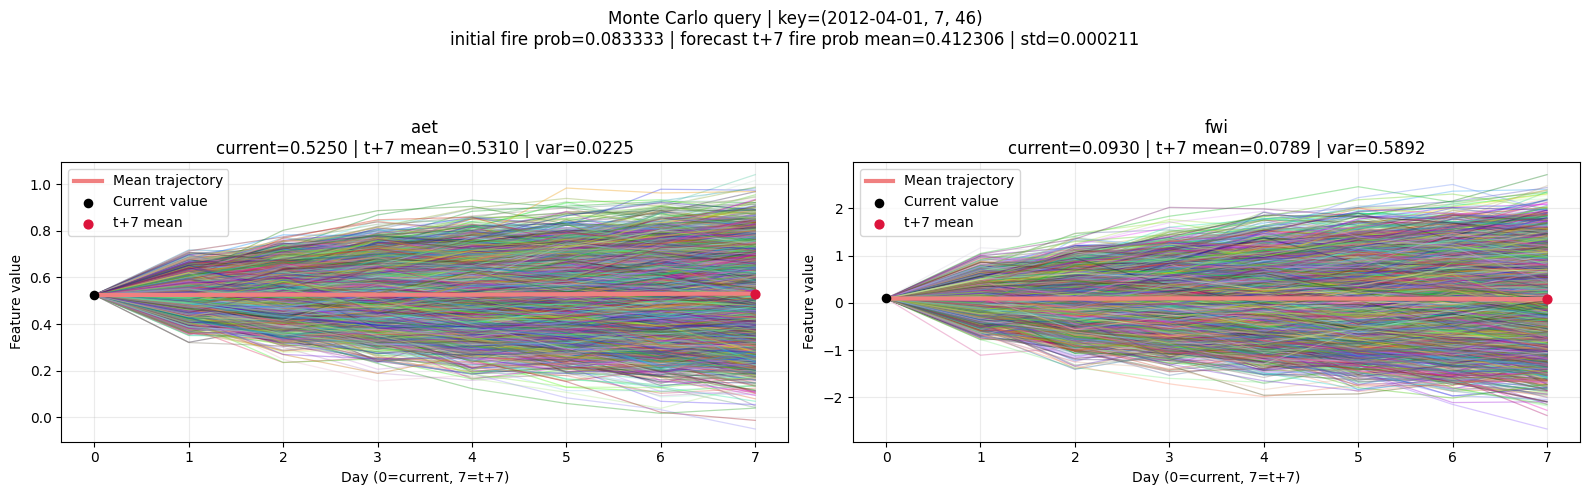

In [12]:

# Final single figure: two-feature spaghetti + mean paths
x_axis = np.arange(HORIZON_DAYS_FOR_PLOT + 1)
plot_feature_names = [QUERY_FEATURE_1, QUERY_FEATURE_2]
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

rng = np.random.default_rng(PLOT_SEED)

for ax, feature_name in zip(axes, plot_feature_names):
    paths = feature_paths[feature_name]
    mean_path = paths.mean(axis=0)
    show_n = min(PLOT_MAX_PATHS, paths.shape[0])
    idx = rng.choice(paths.shape[0], size=show_n, replace=False)
    show_paths = paths[idx]
    colors = rng.random((show_paths.shape[0], 3))

    for i in range(show_paths.shape[0]):
        ax.plot(x_axis, show_paths[i], linewidth=0.9, alpha=0.35, color=colors[i])

    ax.plot(x_axis, mean_path, color='lightcoral', linewidth=3.0, label='Mean trajectory')
    ax.scatter([0], [mean_path[0]], color='black', s=35, zorder=5, label='Current value')
    ax.scatter([HORIZON_DAYS_FOR_PLOT], [mean_path[-1]], color='crimson', s=40, zorder=5, label='t+7 mean')

    summary_row = feature_summary_df[feature_summary_df['feature'] == feature_name].iloc[0]
    ax.set_title(
        f"{feature_name}\n"
        f"current={summary_row['current_day_value']:.4f} | "
        f"t+7 mean={summary_row['t_plus_7_mc_mean_value']:.4f} | "
        f"var={summary_row['t_plus_7_mc_variance']:.4f}"
    )
    ax.set_xlabel('Day (0=current, 7=t+7)')
    ax.set_ylabel('Feature value')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

prob_row = probability_summary_df.iloc[0]
fig.suptitle(
    f"Monte Carlo query | key=({QUERY_TARGET_DATE}, {QUERY_ROW}, {QUERY_COL})\n"
    f"initial fire prob={prob_row['initial_fire_probability_at_t']:.6f} | "
    f"forecast t+7 fire prob mean={prob_row['forecast_fire_probability_t_plus_7_mean']:.6f} | "
    f"std={prob_row['forecast_fire_probability_t_plus_7_std']:.6f}",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()
